In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
data = pd.read_csv("airbnb.csv")

In [3]:
data

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,10,Spacious 2BR,75847,Maria,brooklyn,Greenpoint,40.59158,-73.73783,Private room,97778,5,36,4/9/2019,4.86,19,276
1,286,Cozy apartment near park,84558,Chris,staten island,St. George,40.50063,-74.09041,private room,178,1,377,14/10/2014,0.46,7,179
2,675,Cozy apartment near park,20892,Daniel,QUEENS,Elmhurst,40.88867,-74.02696,entire home/apt,72,365,99,11/8/2013,1.99,19,181
3,100,Cozy apartment near park,90224,Anna,BRONX,Fordham,40.81046,-73.86895,private room,365,1,298,3/17/2018,7.21,8,194
4,668,NaN,35757,John,QUEENS,Ridgewood,40.87452,-73.71388,entire home/apt,244,1,186,1/3/2012,2.05,20,206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1035,920,NaN,35854,Robert,BRONX,Mott Haven,40.54088,-74.04306,Entire home/apt,108,5,296,14/11/2014,5.43,18,422
1036,212,Quiet private room,32502,John,The Bronx,Fordham,40.63243,-73.98257,Shared room,139,1000,271,9/27/2018,NaN,20,342
1037,503,Beautiful loft,43343,Daniel,QUEENS,Astoria,40.55864,-74.04089,PRIVATE ROOM,24482,30,369,2/4/2018,4.28,5,142
1038,538,Quiet private room,43317,David,BROOKLYN,Bedford-Stuyvesant,40.89359,-73.90267,private room,0,1,191,1/8/2012,8.26,14,71


In [4]:
data.isna().sum()

id                                  0
name                              271
host_id                             0
host_name                         127
neighbourhood_group                 0
neighbourhood                       5
latitude                            5
longitude                           0
room_type                           0
price                               0
minimum_nights                      0
number_of_reviews                   0
last_review                        13
reviews_per_month                  54
calculated_host_listings_count      1
availability_365                    0
dtype: int64

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1040 non-null   int64  
 1   name                            769 non-null    str    
 2   host_id                         1040 non-null   str    
 3   host_name                       913 non-null    str    
 4   neighbourhood_group             1040 non-null   str    
 5   neighbourhood                   1035 non-null   str    
 6   latitude                        1035 non-null   float64
 7   longitude                       1040 non-null   str    
 8   room_type                       1040 non-null   str    
 9   price                           1040 non-null   str    
 10  minimum_nights                  1040 non-null   str    
 11  number_of_reviews               1040 non-null   str    
 12  last_review                     1027 non-null

In [6]:
temp = data[data.calculated_host_listings_count.isna()==False]

In [7]:
temp = temp[temp.calculated_host_listings_count.str.isdigit()==True] 

In [8]:
temp.calculated_host_listings_count = temp.calculated_host_listings_count.astype(int)

In [9]:
temp.calculated_host_listings_count.median()

np.float64(10.0)

In [10]:
data.calculated_host_listings_count = data.calculated_host_listings_count.fillna(temp.calculated_host_listings_count.median())

In [11]:
data[data.calculated_host_listings_count.str.isdigit()==False]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
265,777,Sunny room in the heart of NYC,11098,James,Manhattan,Midtown,40.81324,-73.75127,PRIVATE ROOM,56,1,147,8/14/2019,2.37,lksjlsa,100
285,28,Quiet private room,55921,Emma,Queens,Elmhurst,40.80792,-73.72158,Entire home/apt,245,1,391,1/8/2017,NaN,haha,199


In [12]:
data.loc[265,'calculated_host_listings_count'] = temp.calculated_host_listings_count.median()

In [13]:
data.loc[265]

id                                                           777
name                              Sunny room in the heart of NYC
host_id                                                    11098
host_name                                                  James
neighbourhood_group                                    Manhattan
neighbourhood                                            Midtown
latitude                                                40.81324
longitude                                              -73.75127
room_type                                           PRIVATE ROOM
price                                                         56
minimum_nights                                                 1
number_of_reviews                                            147
last_review                                            8/14/2019
reviews_per_month                                           2.37
calculated_host_listings_count                              10.0
availability_365         

In [14]:
data.loc[285,'calculated_host_listings_count'] = temp.calculated_host_listings_count.median()

In [15]:
data.loc[285,'calculated_host_listings_count']

np.float64(10.0)

In [16]:
data.calculated_host_listings_count.isna().sum()

np.int64(0)

In [17]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1040 non-null   int64  
 1   name                            769 non-null    str    
 2   host_id                         1040 non-null   str    
 3   host_name                       913 non-null    str    
 4   neighbourhood_group             1040 non-null   str    
 5   neighbourhood                   1035 non-null   str    
 6   latitude                        1035 non-null   float64
 7   longitude                       1040 non-null   str    
 8   room_type                       1040 non-null   str    
 9   price                           1040 non-null   str    
 10  minimum_nights                  1040 non-null   str    
 11  number_of_reviews               1040 non-null   str    
 12  last_review                     1027 non-null

In [18]:
data.calculated_host_listings_count = data.calculated_host_listings_count.astype(int)

In [19]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1040 non-null   int64  
 1   name                            769 non-null    str    
 2   host_id                         1040 non-null   str    
 3   host_name                       913 non-null    str    
 4   neighbourhood_group             1040 non-null   str    
 5   neighbourhood                   1035 non-null   str    
 6   latitude                        1035 non-null   float64
 7   longitude                       1040 non-null   str    
 8   room_type                       1040 non-null   str    
 9   price                           1040 non-null   str    
 10  minimum_nights                  1040 non-null   str    
 11  number_of_reviews               1040 non-null   str    
 12  last_review                     1027 non-null

In [20]:
data

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,10,Spacious 2BR,75847,Maria,brooklyn,Greenpoint,40.59158,-73.73783,Private room,97778,5,36,4/9/2019,4.86,19,276
1,286,Cozy apartment near park,84558,Chris,staten island,St. George,40.50063,-74.09041,private room,178,1,377,14/10/2014,0.46,7,179
2,675,Cozy apartment near park,20892,Daniel,QUEENS,Elmhurst,40.88867,-74.02696,entire home/apt,72,365,99,11/8/2013,1.99,19,181
3,100,Cozy apartment near park,90224,Anna,BRONX,Fordham,40.81046,-73.86895,private room,365,1,298,3/17/2018,7.21,8,194
4,668,NaN,35757,John,QUEENS,Ridgewood,40.87452,-73.71388,entire home/apt,244,1,186,1/3/2012,2.05,20,206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1035,920,NaN,35854,Robert,BRONX,Mott Haven,40.54088,-74.04306,Entire home/apt,108,5,296,14/11/2014,5.43,18,422
1036,212,Quiet private room,32502,John,The Bronx,Fordham,40.63243,-73.98257,Shared room,139,1000,271,9/27/2018,NaN,20,342
1037,503,Beautiful loft,43343,Daniel,QUEENS,Astoria,40.55864,-74.04089,PRIVATE ROOM,24482,30,369,2/4/2018,4.28,5,142
1038,538,Quiet private room,43317,David,BROOKLYN,Bedford-Stuyvesant,40.89359,-73.90267,private room,0,1,191,1/8/2012,8.26,14,71


In [21]:
data.host_id.isna().sum()

np.int64(0)

In [22]:
data[data.host_id.str.isdigit()==False]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
182,529,NaN,lalsa,Sarah,Manhattan,Upper West Side,40.54907,-74.04327,PRIVATE ROOM,265,3,92,16/02/2012,9.13,1,106
212,797,Modern studio,jdhja,NaN,Queens,Flushing,40.84767,-74.03433,PRIVATE ROOM,388,3,212,8/11/2012,0.43,16,71
235,730,Modern studio,???,NaN,Manhatan,Chelsea,40.64783,-73.71183,Entire Home/Apt,382,1,9,6/14/2018,2.1,16,167


In [23]:
data = data.drop([182,212,235])

In [24]:
data.host_id = data.host_id.astype(int)

In [25]:
data.info()

<class 'pandas.DataFrame'>
Index: 1037 entries, 0 to 1039
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1037 non-null   int64  
 1   name                            767 non-null    str    
 2   host_id                         1037 non-null   int64  
 3   host_name                       912 non-null    str    
 4   neighbourhood_group             1037 non-null   str    
 5   neighbourhood                   1032 non-null   str    
 6   latitude                        1032 non-null   float64
 7   longitude                       1037 non-null   str    
 8   room_type                       1037 non-null   str    
 9   price                           1037 non-null   str    
 10  minimum_nights                  1037 non-null   str    
 11  number_of_reviews               1037 non-null   str    
 12  last_review                     1024 non-null   st

In [26]:
data.isna().sum()

id                                  0
name                              270
host_id                             0
host_name                         125
neighbourhood_group                 0
neighbourhood                       5
latitude                            5
longitude                           0
room_type                           0
price                               0
minimum_nights                      0
number_of_reviews                   0
last_review                        13
reviews_per_month                  54
calculated_host_listings_count      0
availability_365                    0
dtype: int64

In [27]:
data.neighbourhood.mode()[0]

'Tompkinsville'

In [28]:
data.neighbourhood = data.neighbourhood.fillna(data.neighbourhood.mode()[0])

In [29]:
data.isna().sum()

id                                  0
name                              270
host_id                             0
host_name                         125
neighbourhood_group                 0
neighbourhood                       0
latitude                            5
longitude                           0
room_type                           0
price                               0
minimum_nights                      0
number_of_reviews                   0
last_review                        13
reviews_per_month                  54
calculated_host_listings_count      0
availability_365                    0
dtype: int64

In [30]:
data.latitude.median()

np.float64(40.71112)

In [31]:
data.latitude = data.latitude.fillna(data.latitude.median())

In [32]:
data.isna().sum()

id                                  0
name                              270
host_id                             0
host_name                         125
neighbourhood_group                 0
neighbourhood                       0
latitude                            0
longitude                           0
room_type                           0
price                               0
minimum_nights                      0
number_of_reviews                   0
last_review                        13
reviews_per_month                  54
calculated_host_listings_count      0
availability_365                    0
dtype: int64

In [33]:
data.last_review.mode()[0]

'4/1/2018'

In [34]:
data.last_review = data.last_review.fillna(data.last_review.mode()[0])

In [35]:
data.isna().sum()

id                                  0
name                              270
host_id                             0
host_name                         125
neighbourhood_group                 0
neighbourhood                       0
latitude                            0
longitude                           0
room_type                           0
price                               0
minimum_nights                      0
number_of_reviews                   0
last_review                         0
reviews_per_month                  54
calculated_host_listings_count      0
availability_365                    0
dtype: int64

In [36]:
data[data.reviews_per_month.str.contains("\?\?")==True]

<>:1: SyntaxWarning: invalid escape sequence '\?'
<>:1: SyntaxWarning: invalid escape sequence '\?'
C:\Users\Khizar\AppData\Local\Temp\ipykernel_33256\898800776.py:1: SyntaxWarning: invalid escape sequence '\?'
  data[data.reviews_per_month.str.contains("\?\?")==True]


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
266,128,NaN,73642,Olivia,Queens,Astoria,40.60791,-74.047,Entire home/apt,257,1,220,9/18/2018,??,3,13


In [37]:
data.loc[266,'reviews_per_month'] = None

In [38]:
data.loc[266]

id                                            128
name                                          NaN
host_id                                     73642
host_name                                  Olivia
neighbourhood_group                        Queens
neighbourhood                             Astoria
latitude                                 40.60791
longitude                                 -74.047
room_type                         Entire home/apt
price                                         257
minimum_nights                                  1
number_of_reviews                             220
last_review                             9/18/2018
reviews_per_month                             NaN
calculated_host_listings_count                  3
availability_365                               13
Name: 266, dtype: object

In [39]:
data.reviews_per_month = data.reviews_per_month.astype(float)

In [40]:
data.reviews_per_month.median()

np.float64(4.6899999999999995)

In [41]:
round(data.reviews_per_month.median(),2)

np.float64(4.69)

In [42]:
data.reviews_per_month = data.reviews_per_month.fillna(round(data.reviews_per_month.median(),2))

In [43]:
data.isna().sum()

id                                  0
name                              270
host_id                             0
host_name                         125
neighbourhood_group                 0
neighbourhood                       0
latitude                            0
longitude                           0
room_type                           0
price                               0
minimum_nights                      0
number_of_reviews                   0
last_review                         0
reviews_per_month                   0
calculated_host_listings_count      0
availability_365                    0
dtype: int64

In [44]:
data.host_name = data.host_name.fillna(data.host_name.mode()[0])

In [45]:
data.isna().sum()

id                                  0
name                              270
host_id                             0
host_name                           0
neighbourhood_group                 0
neighbourhood                       0
latitude                            0
longitude                           0
room_type                           0
price                               0
minimum_nights                      0
number_of_reviews                   0
last_review                         0
reviews_per_month                   0
calculated_host_listings_count      0
availability_365                    0
dtype: int64

In [46]:
data.name = data.name.fillna(data.name.mode()[0])

In [47]:
data.isna().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [48]:
data.info()

<class 'pandas.DataFrame'>
Index: 1037 entries, 0 to 1039
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1037 non-null   int64  
 1   name                            1037 non-null   str    
 2   host_id                         1037 non-null   int64  
 3   host_name                       1037 non-null   str    
 4   neighbourhood_group             1037 non-null   str    
 5   neighbourhood                   1037 non-null   str    
 6   latitude                        1037 non-null   float64
 7   longitude                       1037 non-null   str    
 8   room_type                       1037 non-null   str    
 9   price                           1037 non-null   str    
 10  minimum_nights                  1037 non-null   str    
 11  number_of_reviews               1037 non-null   str    
 12  last_review                     1037 non-null   st

In [49]:
data[data.longitude.str.isalnum()==True]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
616,895,Spacious 2BR,16095,John,MANHATTAN,Chelsea,40.74483,haha,Entire Home/Apt,291,1,295,8/3/2017,6.87,5,255


In [50]:
data.loc[616,"longitude"] = None

In [51]:
data.longitude.astype(float)

ValueError: could not convert string to float: '???'

In [52]:
data[data.longitude.str.contains("\?")]

<>:1: SyntaxWarning: invalid escape sequence '\?'
<>:1: SyntaxWarning: invalid escape sequence '\?'
C:\Users\Khizar\AppData\Local\Temp\ipykernel_33256\2507930447.py:1: SyntaxWarning: invalid escape sequence '\?'
  data[data.longitude.str.contains("\?")]


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
576,246,Modern studio,86830,Maria,Manhatan,Harlem,40.87472,???,Private room,$82,1,13,9/25/2017,1.05,13,316


In [53]:
data.loc[576,"longitude"] = None

In [54]:
data.longitude = data.longitude.astype(float)

In [55]:
data.longitude.median()

np.float64(-73.90403)

In [56]:
data.longitude = data.longitude.fillna(data.longitude.median())

In [57]:
data

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,10,Spacious 2BR,75847,Maria,brooklyn,Greenpoint,40.59158,-73.73783,Private room,97778,5,36,4/9/2019,4.86,19,276
1,286,Cozy apartment near park,84558,Chris,staten island,St. George,40.50063,-74.09041,private room,178,1,377,14/10/2014,0.46,7,179
2,675,Cozy apartment near park,20892,Daniel,QUEENS,Elmhurst,40.88867,-74.02696,entire home/apt,72,365,99,11/8/2013,1.99,19,181
3,100,Cozy apartment near park,90224,Anna,BRONX,Fordham,40.81046,-73.86895,private room,365,1,298,3/17/2018,7.21,8,194
4,668,Spacious 2BR,35757,John,QUEENS,Ridgewood,40.87452,-73.71388,entire home/apt,244,1,186,1/3/2012,2.05,20,206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1035,920,Spacious 2BR,35854,Robert,BRONX,Mott Haven,40.54088,-74.04306,Entire home/apt,108,5,296,14/11/2014,5.43,18,422
1036,212,Quiet private room,32502,John,The Bronx,Fordham,40.63243,-73.98257,Shared room,139,1000,271,9/27/2018,4.69,20,342
1037,503,Beautiful loft,43343,Daniel,QUEENS,Astoria,40.55864,-74.04089,PRIVATE ROOM,24482,30,369,2/4/2018,4.28,5,142
1038,538,Quiet private room,43317,David,BROOKLYN,Bedford-Stuyvesant,40.89359,-73.90267,private room,0,1,191,1/8/2012,8.26,14,71


In [58]:
data.info()

<class 'pandas.DataFrame'>
Index: 1037 entries, 0 to 1039
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1037 non-null   int64  
 1   name                            1037 non-null   str    
 2   host_id                         1037 non-null   int64  
 3   host_name                       1037 non-null   str    
 4   neighbourhood_group             1037 non-null   str    
 5   neighbourhood                   1037 non-null   str    
 6   latitude                        1037 non-null   float64
 7   longitude                       1037 non-null   float64
 8   room_type                       1037 non-null   str    
 9   price                           1037 non-null   str    
 10  minimum_nights                  1037 non-null   str    
 11  number_of_reviews               1037 non-null   str    
 12  last_review                     1037 non-null   st

In [59]:
data.price.astype(int)

ValueError: invalid literal for int() with base 10: '$366 '

In [60]:
data[data.price.str.isalnum() == False]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
11,473,Quiet private room,69506,Sofia,BRONX,Riverdale,40.62024,-73.72151,private room,$366,365,400,18/11/2015,1.41,12,251
15,409,Sunny room in the heart of NYC,22157,James,Staten island,Tompkinsville,40.86872,-73.99068,Entire Home/Apt,$30,3,348,6/27/2017,2.14,18,261
17,578,Spacious 2BR,80996,Sarah,QUEENS,Flushing,40.50355,-74.08520,PRIVATE ROOM,$266,5,245,4/14/2019,5.80,18,40
20,453,Quiet private room,77829,Michael,BROOKLYN,Kensington,40.68219,-73.82757,Entire Home/Apt,??,3,126,1/4/2013,6.45,3,196
21,519,Spacious 2BR,91819,Olivia,Manhatan,Midtown,40.80127,-74.03419,PRIVATE ROOM,-269,5,214,8/18/2018,7.84,19,356
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017,313,Spacious 2BR,68552,Michael,Brooklyn,Greenpoint,40.69908,-73.83885,Entire Home/Apt,$258,1,19,5/5/2017,3.31,16,200
1019,961,Cozy apartment near park,24956,Robert,Manhattan,Chelsea,40.61068,-74.07995,Shared room,-467,5,229,3/6/2016,9.61,1,81
1023,950,Spacious 2BR,73521,Michael,staten island,St. George,40.53479,-73.92735,Entire Home/Apt,$94,5,232,10/18/2019,3.81,1,154
1024,184,Spacious 2BR,56549,Emma,Manhatan,East Village,40.86461,-73.84105,private room,"$94,417",1000,4,20/05/2014,7.13,13,363


In [61]:
data.price = data.price.str.replace('$',"").replace(",","").replace(" ","")

In [62]:
data.price.astype(int)

ValueError: invalid literal for int() with base 10: '??'

In [63]:
data[data.price.str.contains("\?")]

<>:1: SyntaxWarning: invalid escape sequence '\?'
<>:1: SyntaxWarning: invalid escape sequence '\?'
C:\Users\Khizar\AppData\Local\Temp\ipykernel_33256\2777396737.py:1: SyntaxWarning: invalid escape sequence '\?'
  data[data.price.str.contains("\?")]


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
20,453,Quiet private room,77829,Michael,BROOKLYN,Kensington,40.68219,-73.82757,Entire Home/Apt,??,3,126,1/4/2013,6.45,3,196
405,599,Cozy apartment near park,31147,James,Manhatan,Chelsea,40.50546,-73.76181,entire home/apt,???,365,52,26/07/2019,0.43,8,144


In [64]:
data.loc[20,"price"] = None

In [65]:
data.loc[405,"price"] = None

In [66]:
data.price.astype(int)

ValueError: cannot convert float NaN to integer

In [67]:
data[data.price.str.isdigit() == False]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
11,473,Quiet private room,69506,Sofia,BRONX,Riverdale,40.62024,-73.72151,private room,366,365,400,18/11/2015,1.41,12,251
15,409,Sunny room in the heart of NYC,22157,James,Staten island,Tompkinsville,40.86872,-73.99068,Entire Home/Apt,30,3,348,6/27/2017,2.14,18,261
17,578,Spacious 2BR,80996,Sarah,QUEENS,Flushing,40.50355,-74.08520,PRIVATE ROOM,266,5,245,4/14/2019,5.80,18,40
20,453,Quiet private room,77829,Michael,BROOKLYN,Kensington,40.68219,-73.82757,Entire Home/Apt,NaN,3,126,1/4/2013,6.45,3,196
21,519,Spacious 2BR,91819,Olivia,Manhatan,Midtown,40.80127,-74.03419,PRIVATE ROOM,-269,5,214,8/18/2018,7.84,19,356
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017,313,Spacious 2BR,68552,Michael,Brooklyn,Greenpoint,40.69908,-73.83885,Entire Home/Apt,258,1,19,5/5/2017,3.31,16,200
1019,961,Cozy apartment near park,24956,Robert,Manhattan,Chelsea,40.61068,-74.07995,Shared room,-467,5,229,3/6/2016,9.61,1,81
1023,950,Spacious 2BR,73521,Michael,staten island,St. George,40.53479,-73.92735,Entire Home/Apt,94,5,232,10/18/2019,3.81,1,154
1024,184,Spacious 2BR,56549,Emma,Manhatan,East Village,40.86461,-73.84105,private room,"94,417",1000,4,20/05/2014,7.13,13,363


In [68]:
data.price = data.price.str.replace(",","")

In [69]:
data.price = data.price.str.replace(" ","")

In [70]:
data[data.price.str.isdigit() == False]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
20,453,Quiet private room,77829,Michael,BROOKLYN,Kensington,40.68219,-73.82757,Entire Home/Apt,NaN,3,126,1/4/2013,6.45,3,196
21,519,Spacious 2BR,91819,Olivia,Manhatan,Midtown,40.80127,-74.03419,PRIVATE ROOM,-269,5,214,8/18/2018,7.84,19,356
39,447,Spacious 2BR,91092,Robert,QUEENS,Astoria,40.61538,-74.09052,private room,,5,175,4/18/2014,9.07,8,340
54,99,Sunny room in the heart of NYC,49281,Michael,bronx,Riverdale,40.79573,-73.98031,private room,000.000l,5,259,9/16/2019,5.63,11,243
64,866,Spacious 2BR,24651,Lisa,Brooklyn,Bedford-Stuyvesant,40.59438,-73.93797,Entire Home/Apt,-490,1,7,1/13/2016,1.44,8,337
68,421,Sunny room in the heart of NYC,27263,Lisa,bronx,Mott Haven,40.88811,-73.89293,entire home/apt,205jsask,1,29,9/27/2014,4.69,7,216
78,753,Sunny room in the heart of NYC,51299,Michael,staten island,St. George,40.75409,-73.86267,Shared room,none,30,16,6/12/2018,2.57,18,242
82,223,Modern studio,69337,Anna,brooklyn,Bedford-Stuyvesant,40.76743,-73.89285,Private room,-239,5,198,8/2/2018,9.81,9,165
83,26,Modern studio,63216,Daniel,Brooklyn,Williamsburg,40.73818,-73.71998,PRIVATE ROOM,301knskj,30,313,7/27/2019,4.46,15,81
90,359,Modern studio,55304,Anna,Bronx,Riverdale,40.67084,-73.96107,Shared room,-460,1,333,26/09/2015,4.33,13,276


In [71]:
data.price = data.price.str.replace("(","")

In [72]:
data.price = data.price.str.replace(")","")

In [73]:
data.price = data.price.str.replace("-","")

In [74]:
data[data.price.str.isdigit() == False]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
20,453,Quiet private room,77829,Michael,BROOKLYN,Kensington,40.68219,-73.82757,Entire Home/Apt,NaN,3,126,1/4/2013,6.45,3,196
39,447,Spacious 2BR,91092,Robert,QUEENS,Astoria,40.61538,-74.09052,private room,,5,175,4/18/2014,9.07,8,340
54,99,Sunny room in the heart of NYC,49281,Michael,bronx,Riverdale,40.79573,-73.98031,private room,000.000l,5,259,9/16/2019,5.63,11,243
68,421,Sunny room in the heart of NYC,27263,Lisa,bronx,Mott Haven,40.88811,-73.89293,entire home/apt,205jsask,1,29,9/27/2014,4.69,7,216
78,753,Sunny room in the heart of NYC,51299,Michael,staten island,St. George,40.75409,-73.86267,Shared room,none,30,16,6/12/2018,2.57,18,242
83,26,Modern studio,63216,Daniel,Brooklyn,Williamsburg,40.73818,-73.71998,PRIVATE ROOM,301knskj,30,313,7/27/2019,4.46,15,81
110,98,Beautiful loft,69069,Anna,Brooklyn,Bushwick,40.80199,-74.02038,PRIVATE ROOM,kj,365,205,1/2/2019,1.38,15,170
128,563,Sunny room in the heart of NYC,97029,Michael,QUEENS,Ridgewood,40.84081,-74.03633,private room,ks,1,340,22/08/2012,3.24,8,118
150,596,Spacious 2BR,54609,James,staten island,Stapleton,40.80947,-73.90650,Entire home/apt,kjks,30,307,11/8/2017,2.92,2,259
405,599,Cozy apartment near park,31147,James,Manhatan,Chelsea,40.50546,-73.76181,entire home/apt,NaN,365,52,26/07/2019,0.43,8,144


In [75]:
data.loc[[20,39,54,68,78,83,110,128,150],"price"] = None

In [76]:
data[data.price.str.isdigit() == False]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
20,453,Quiet private room,77829,Michael,BROOKLYN,Kensington,40.68219,-73.82757,Entire Home/Apt,NaN,3,126,1/4/2013,6.45,3,196
39,447,Spacious 2BR,91092,Robert,QUEENS,Astoria,40.61538,-74.09052,private room,NaN,5,175,4/18/2014,9.07,8,340
54,99,Sunny room in the heart of NYC,49281,Michael,bronx,Riverdale,40.79573,-73.98031,private room,NaN,5,259,9/16/2019,5.63,11,243
68,421,Sunny room in the heart of NYC,27263,Lisa,bronx,Mott Haven,40.88811,-73.89293,entire home/apt,NaN,1,29,9/27/2014,4.69,7,216
78,753,Sunny room in the heart of NYC,51299,Michael,staten island,St. George,40.75409,-73.86267,Shared room,NaN,30,16,6/12/2018,2.57,18,242
83,26,Modern studio,63216,Daniel,Brooklyn,Williamsburg,40.73818,-73.71998,PRIVATE ROOM,NaN,30,313,7/27/2019,4.46,15,81
110,98,Beautiful loft,69069,Anna,Brooklyn,Bushwick,40.80199,-74.02038,PRIVATE ROOM,NaN,365,205,1/2/2019,1.38,15,170
128,563,Sunny room in the heart of NYC,97029,Michael,QUEENS,Ridgewood,40.84081,-74.03633,private room,NaN,1,340,22/08/2012,3.24,8,118
150,596,Spacious 2BR,54609,James,staten island,Stapleton,40.80947,-73.90650,Entire home/apt,NaN,30,307,11/8/2017,2.92,2,259
405,599,Cozy apartment near park,31147,James,Manhatan,Chelsea,40.50546,-73.76181,entire home/apt,NaN,365,52,26/07/2019,0.43,8,144


In [79]:
data[(data.price == 0) | (data.price == '0')].index

Index([  16,   59,  129,  143,  155,  181,  229,  250,  281,  314,  335,  353,
        475,  493,  517,  601,  602,  660,  772,  793,  844,  865,  876,  985,
       1000, 1038],
      dtype='int64')

In [80]:
data.loc[data[(data.price == 0) | (data.price == '0')].index,"price"] = None

In [81]:
data[(data.price == 0) | (data.price == '0')]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365


In [82]:
data.price = data.price.astype(float)

In [83]:
data.price.median()

np.float64(269.0)

In [84]:
data.price.isna().sum()

np.int64(36)

In [85]:
data.price = data.price.fillna(data.price.median())

In [86]:
data.price = data.price.astype(int)

In [87]:
data.isna().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [88]:
data

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,10,Spacious 2BR,75847,Maria,brooklyn,Greenpoint,40.59158,-73.73783,Private room,97778,5,36,4/9/2019,4.86,19,276
1,286,Cozy apartment near park,84558,Chris,staten island,St. George,40.50063,-74.09041,private room,178,1,377,14/10/2014,0.46,7,179
2,675,Cozy apartment near park,20892,Daniel,QUEENS,Elmhurst,40.88867,-74.02696,entire home/apt,72,365,99,11/8/2013,1.99,19,181
3,100,Cozy apartment near park,90224,Anna,BRONX,Fordham,40.81046,-73.86895,private room,365,1,298,3/17/2018,7.21,8,194
4,668,Spacious 2BR,35757,John,QUEENS,Ridgewood,40.87452,-73.71388,entire home/apt,244,1,186,1/3/2012,2.05,20,206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1035,920,Spacious 2BR,35854,Robert,BRONX,Mott Haven,40.54088,-74.04306,Entire home/apt,108,5,296,14/11/2014,5.43,18,422
1036,212,Quiet private room,32502,John,The Bronx,Fordham,40.63243,-73.98257,Shared room,139,1000,271,9/27/2018,4.69,20,342
1037,503,Beautiful loft,43343,Daniel,QUEENS,Astoria,40.55864,-74.04089,PRIVATE ROOM,24482,30,369,2/4/2018,4.28,5,142
1038,538,Quiet private room,43317,David,BROOKLYN,Bedford-Stuyvesant,40.89359,-73.90267,private room,269,1,191,1/8/2012,8.26,14,71


In [89]:
data.info()

<class 'pandas.DataFrame'>
Index: 1037 entries, 0 to 1039
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1037 non-null   int64  
 1   name                            1037 non-null   str    
 2   host_id                         1037 non-null   int64  
 3   host_name                       1037 non-null   str    
 4   neighbourhood_group             1037 non-null   str    
 5   neighbourhood                   1037 non-null   str    
 6   latitude                        1037 non-null   float64
 7   longitude                       1037 non-null   float64
 8   room_type                       1037 non-null   str    
 9   price                           1037 non-null   int64  
 10  minimum_nights                  1037 non-null   str    
 11  number_of_reviews               1037 non-null   str    
 12  last_review                     1037 non-null   st

In [90]:
data.minimum_nights.astype(int)

ValueError: invalid literal for int() with base 10: 'kjsk'

In [91]:
data[data.minimum_nights.str.isdigit() == False]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
163,58,Cozy apartment near park,85518,Michael,MANHATTAN,Harlem,40.61190,-73.82389,PRIVATE ROOM,238,kjsk,227,28/04/2018,1.00,12,351
173,557,Beautiful loft,98048,Maria,BROOKLYN,Greenpoint,40.63252,-74.07565,Entire home/apt,319,msajks,345,12/23/2019,7.02,16,264
186,206,Modern studio,28487,Michael,staten island,Tompkinsville,40.78001,-73.80063,entire home/apt,100,jsakj,359,6/23/2019,9.36,20,323
268,386,Spacious 2BR,2032,Michael,Staten Island,St. George,40.88555,-73.91140,Private room,408,jalkjsa,299,4/10/2014,8.30,4,200
372,446,Spacious 2BR,79390,Michael,Brooklyn,Bushwick,40.53176,-74.04498,Private room,417,aa,151,3/13/2014,6.42,15,121


In [92]:
data.loc[[163,173,186,268,372],"minimum_nights"] = None

In [93]:
data.minimum_nights.isna().sum()

np.int64(5)

In [94]:
data.minimum_nights = data.minimum_nights.astype(float)

In [95]:
data.minimum_nights.median()

np.float64(5.0)

In [96]:
data.minimum_nights = data.minimum_nights.fillna(data.minimum_nights.median())

In [97]:
data.minimum_nights = data.minimum_nights.astype(int)

In [98]:
data.info()

<class 'pandas.DataFrame'>
Index: 1037 entries, 0 to 1039
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1037 non-null   int64  
 1   name                            1037 non-null   str    
 2   host_id                         1037 non-null   int64  
 3   host_name                       1037 non-null   str    
 4   neighbourhood_group             1037 non-null   str    
 5   neighbourhood                   1037 non-null   str    
 6   latitude                        1037 non-null   float64
 7   longitude                       1037 non-null   float64
 8   room_type                       1037 non-null   str    
 9   price                           1037 non-null   int64  
 10  minimum_nights                  1037 non-null   int64  
 11  number_of_reviews               1037 non-null   str    
 12  last_review                     1037 non-null   st

In [99]:
data[data.number_of_reviews.str.isdigit()==False]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
248,958,Cozy apartment near park,96073,James,bronx,Concourse,40.68889,-74.05377,Shared room,161,1,kas;ksa,3/16/2019,8.05,3,275
263,327,Cozy apartment near park,93183,Emma,Brooklyn,Bedford-Stuyvesant,40.79271,-73.72003,Private room,415,1,kjslkjs,4/21/2015,0.17,15,342


In [100]:
data.loc[[248,263],"number_of_reviews"] = None

In [101]:
data.number_of_reviews = data.number_of_reviews.astype(float)

In [102]:
data.number_of_reviews.median()

np.float64(210.0)

In [103]:
data.number_of_reviews = data.number_of_reviews.fillna(data.number_of_reviews.median())

In [104]:
data.number_of_reviews = data.number_of_reviews.astype(int)

In [105]:
data.info()

<class 'pandas.DataFrame'>
Index: 1037 entries, 0 to 1039
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1037 non-null   int64  
 1   name                            1037 non-null   str    
 2   host_id                         1037 non-null   int64  
 3   host_name                       1037 non-null   str    
 4   neighbourhood_group             1037 non-null   str    
 5   neighbourhood                   1037 non-null   str    
 6   latitude                        1037 non-null   float64
 7   longitude                       1037 non-null   float64
 8   room_type                       1037 non-null   str    
 9   price                           1037 non-null   int64  
 10  minimum_nights                  1037 non-null   int64  
 11  number_of_reviews               1037 non-null   int64  
 12  last_review                     1037 non-null   st

In [106]:
data[data.duplicated()==True]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
81,473,Quiet private room,69506,Sofia,BRONX,Riverdale,40.62024,-73.72151,private room,366,365,400,18/11/2015,1.41,12,251
276,930,Spacious 2BR,44778,Maria,Bronx,Concourse,40.81957,-73.74965,Private room,430,1,324,7/11/2013,2.90,20,55
278,243,Spacious 2BR,54970,Olivia,Queens,Elmhurst,40.60172,-73.76441,Entire home/apt,60,1,230,12/5/2016,5.61,4,131
341,263,Spacious 2BR,19141,Michael,queens,Long Island City,40.77589,-73.98962,PRIVATE ROOM,425,365,261,10/19/2019,0.95,9,235
409,7,Quiet private room,40117,David,Brooklyn,Greenpoint,40.61740,-74.03674,PRIVATE ROOM,358,1,369,9/25/2015,5.08,17,54
442,645,Modern studio,74864,James,Staten Island,Tompkinsville,40.68015,-73.99683,Shared room,257,3,304,3/5/2011,2.89,12,113
457,719,Cozy apartment near park,50809,Sofia,staten island,St. George,40.76376,-73.96683,Shared room,418,1,66,12/19/2011,3.03,13,102
480,508,Spacious 2BR,13050,David,brooklyn,Greenpoint,40.85039,-73.87834,Private room,60524,3,292,5/23/2019,4.24,17,80
515,703,Spacious 2BR,55511,Michael,Staten Island,Tompkinsville,40.59847,-73.83259,PRIVATE ROOM,109,7,348,4/21/2015,9.14,14,209
567,109,Spacious 2BR,60634,Michael,Brooklyn,Bushwick,40.85512,-73.79206,Private room,287,1,327,6/20/2015,2.20,20,68


In [107]:
data.drop_duplicates(inplace=True, ignore_index=True)

In [108]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1006 entries, 0 to 1005
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1006 non-null   int64  
 1   name                            1006 non-null   str    
 2   host_id                         1006 non-null   int64  
 3   host_name                       1006 non-null   str    
 4   neighbourhood_group             1006 non-null   str    
 5   neighbourhood                   1006 non-null   str    
 6   latitude                        1006 non-null   float64
 7   longitude                       1006 non-null   float64
 8   room_type                       1006 non-null   str    
 9   price                           1006 non-null   int64  
 10  minimum_nights                  1006 non-null   int64  
 11  number_of_reviews               1006 non-null   int64  
 12  last_review                     1006 non-null

In [109]:
data.isna().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

<Axes: xlabel='price'>

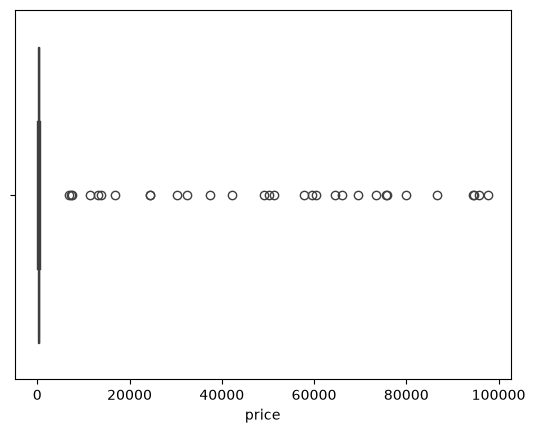

In [110]:
sb.boxplot(data.price,orient='h')

In [111]:
data.price.min(),data.price.max()

(np.int64(30), np.int64(97778))

In [112]:
price_bin = [0,20000,40000,60000,80000,100000]

In [113]:
price_cat = pd.cut(data.price, price_bin,labels=['Cheaper','Cheap','Normal',
                                    "Expensive","Very Expensive"])

In [114]:
data["price_category"] = price_cat

In [115]:
data

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,price_category
0,10,Spacious 2BR,75847,Maria,brooklyn,Greenpoint,40.59158,-73.73783,Private room,97778,5,36,4/9/2019,4.86,19,276,Very Expensive
1,286,Cozy apartment near park,84558,Chris,staten island,St. George,40.50063,-74.09041,private room,178,1,377,14/10/2014,0.46,7,179,Cheaper
2,675,Cozy apartment near park,20892,Daniel,QUEENS,Elmhurst,40.88867,-74.02696,entire home/apt,72,365,99,11/8/2013,1.99,19,181,Cheaper
3,100,Cozy apartment near park,90224,Anna,BRONX,Fordham,40.81046,-73.86895,private room,365,1,298,3/17/2018,7.21,8,194,Cheaper
4,668,Spacious 2BR,35757,John,QUEENS,Ridgewood,40.87452,-73.71388,entire home/apt,244,1,186,1/3/2012,2.05,20,206,Cheaper
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1001,920,Spacious 2BR,35854,Robert,BRONX,Mott Haven,40.54088,-74.04306,Entire home/apt,108,5,296,14/11/2014,5.43,18,422,Cheaper
1002,212,Quiet private room,32502,John,The Bronx,Fordham,40.63243,-73.98257,Shared room,139,1000,271,9/27/2018,4.69,20,342,Cheaper
1003,503,Beautiful loft,43343,Daniel,QUEENS,Astoria,40.55864,-74.04089,PRIVATE ROOM,24482,30,369,2/4/2018,4.28,5,142,Cheap
1004,538,Quiet private room,43317,David,BROOKLYN,Bedford-Stuyvesant,40.89359,-73.90267,private room,269,1,191,1/8/2012,8.26,14,71,Cheaper


In [116]:
data[data.price_category.isna() == True]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,price_category


In [117]:
price_cats = price_cat.value_counts()

In [118]:
price_cats

price
Cheaper           982
Expensive           8
Normal              6
Cheap               5
Very Expensive      5
Name: count, dtype: int64

<BarContainer object of 5 artists>

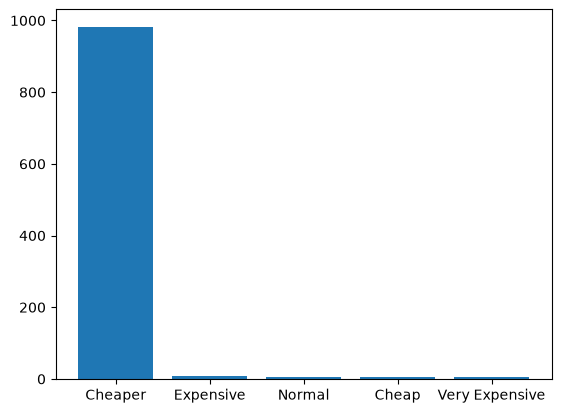

In [119]:
plt.bar(x=price_cats.index,height=price_cats.values)

<Axes: xlabel='minimum_nights'>

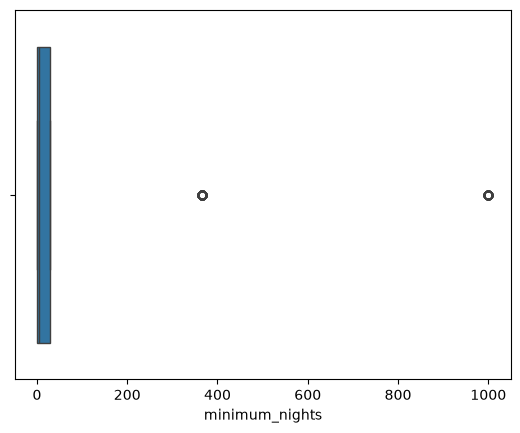

In [120]:
sb.boxplot(data.minimum_nights,orient='h')

In [121]:
data.minimum_nights.min(),data.minimum_nights.max()

(np.int64(1), np.int64(1000))

In [122]:
min_nights_bin = [0,5,20,50,500,1000]

In [123]:
min_nights_cat = pd.cut(data.minimum_nights, min_nights_bin,labels=['Very Short','Short','Normal',"Long","Very Long"])

In [124]:
data["minimum_nights_category"] = min_nights_cat

In [125]:
data

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,price_category,minimum_nights_category
0,10,Spacious 2BR,75847,Maria,brooklyn,Greenpoint,40.59158,-73.73783,Private room,97778,5,36,4/9/2019,4.86,19,276,Very Expensive,Very Short
1,286,Cozy apartment near park,84558,Chris,staten island,St. George,40.50063,-74.09041,private room,178,1,377,14/10/2014,0.46,7,179,Cheaper,Very Short
2,675,Cozy apartment near park,20892,Daniel,QUEENS,Elmhurst,40.88867,-74.02696,entire home/apt,72,365,99,11/8/2013,1.99,19,181,Cheaper,Long
3,100,Cozy apartment near park,90224,Anna,BRONX,Fordham,40.81046,-73.86895,private room,365,1,298,3/17/2018,7.21,8,194,Cheaper,Very Short
4,668,Spacious 2BR,35757,John,QUEENS,Ridgewood,40.87452,-73.71388,entire home/apt,244,1,186,1/3/2012,2.05,20,206,Cheaper,Very Short
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1001,920,Spacious 2BR,35854,Robert,BRONX,Mott Haven,40.54088,-74.04306,Entire home/apt,108,5,296,14/11/2014,5.43,18,422,Cheaper,Very Short
1002,212,Quiet private room,32502,John,The Bronx,Fordham,40.63243,-73.98257,Shared room,139,1000,271,9/27/2018,4.69,20,342,Cheaper,Very Long
1003,503,Beautiful loft,43343,Daniel,QUEENS,Astoria,40.55864,-74.04089,PRIVATE ROOM,24482,30,369,2/4/2018,4.28,5,142,Cheap,Normal
1004,538,Quiet private room,43317,David,BROOKLYN,Bedford-Stuyvesant,40.89359,-73.90267,private room,269,1,191,1/8/2012,8.26,14,71,Cheaper,Very Short


In [126]:
min_nights_cat = min_nights_cat.value_counts()

In [127]:
min_nights_cat

minimum_nights
Very Short    601
Long          114
Short         104
Normal        102
Very Long      85
Name: count, dtype: int64

<BarContainer object of 5 artists>

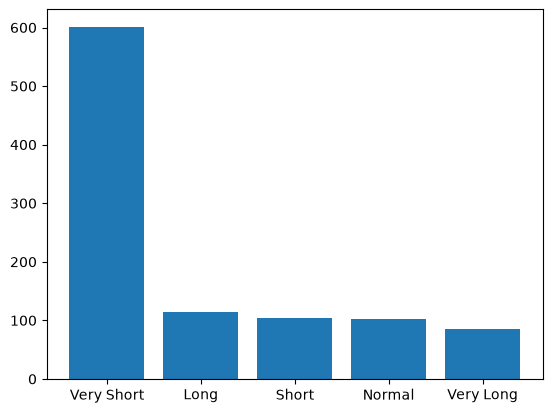

In [128]:
plt.bar(x=min_nights_cat.index,height=min_nights_cat.values)

<Axes: xlabel='number_of_reviews'>

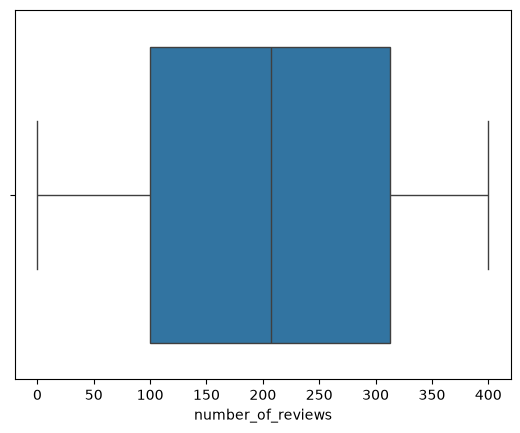

In [129]:
sb.boxplot(data.number_of_reviews,orient='h')

<Axes: xlabel='reviews_per_month'>

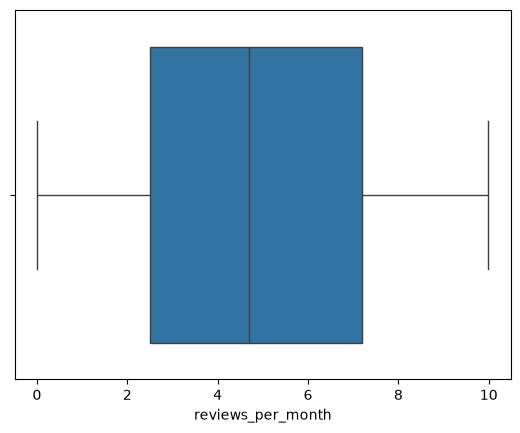

In [130]:
sb.boxplot(data.reviews_per_month,orient='h')

<Axes: xlabel='calculated_host_listings_count'>

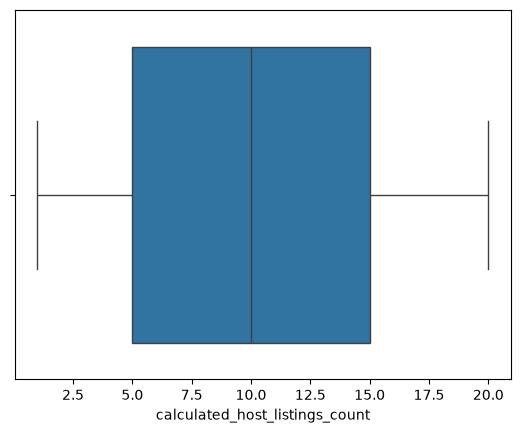

In [131]:
sb.boxplot(data.calculated_host_listings_count,orient='h')

<Axes: xlabel='availability_365'>

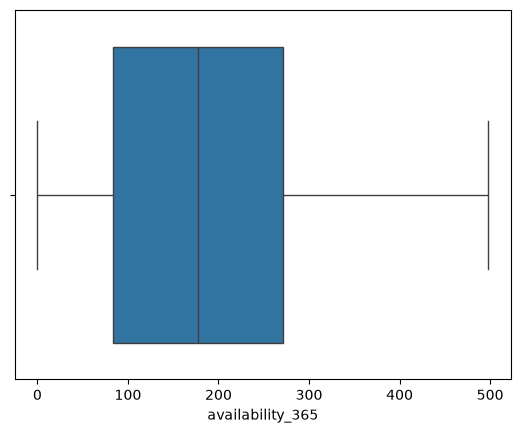

In [132]:
sb.boxplot(data.availability_365,orient='h')

In [133]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1006 entries, 0 to 1005
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   id                              1006 non-null   int64   
 1   name                            1006 non-null   str     
 2   host_id                         1006 non-null   int64   
 3   host_name                       1006 non-null   str     
 4   neighbourhood_group             1006 non-null   str     
 5   neighbourhood                   1006 non-null   str     
 6   latitude                        1006 non-null   float64 
 7   longitude                       1006 non-null   float64 
 8   room_type                       1006 non-null   str     
 9   price                           1006 non-null   int64   
 10  minimum_nights                  1006 non-null   int64   
 11  number_of_reviews               1006 non-null   int64   
 12  last_review                    

In [134]:
data.isna().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
price_category                    0
minimum_nights_category           0
dtype: int64

In [135]:
data.isnull().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
price_category                    0
minimum_nights_category           0
dtype: int64